# 02 — Indices: NBR, NDVI, dNBR, FIREMON severity

Inputs: the outputs of `01_data` (run it first in the same Colab runtime).
Outputs: `data/dnbr_2023_2025.tif`, `data/severity_2023_2025.tif`, `figures/severity_map.png`

In [1]:
![ -d /content/jasper-burn-severity ] || git clone https://github.com/MegaDeadCowboy/jasper-burn-severity.git /content/jasper-burn-severity
%cd /content/jasper-burn-severity
!pip install -q rioxarray geopandas

Cloning into '/content/jasper-burn-severity'...
remote: Enumerating objects: 35, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 35 (delta 14), reused 28 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (35/35), 975.29 KiB | 12.67 MiB/s, done.
Resolving deltas: 100% (14/14), done.
/content/jasper-burn-severity
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 23.8 MB/s eta 0:00:00


In [7]:
import sys; sys.path.insert(0, ".")
from pathlib import Path
import numpy as np, pandas as pd, geopandas as gpd, xarray as xr, rioxarray
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from src.indices import ndvi, nbr, dnbr, classify_severity, SEVERITY_LABELS
from google.colab import drive; drive.mount("/content/drive")

DATA = Path("/content/drive/MyDrive/jasper-burn-severity/data"); DATA.mkdir(parents=True, exist_ok=True)
FIG = Path("figures"); FIG.mkdir(exist_ok=True)
UTM, PIX_HA = 32611, 20 * 20 / 10_000          # 0.04 ha per 20 m pixel
BANDS = ["B04", "B08", "B8A", "B12"]           # band order written by 01_data
for f in ["s2_pre_2023.tif", "s2_post_2025.tif", "nbac_jasper_2024.gpkg"]:
    assert (DATA / f).exists(), f"missing {f}: run 01_data first in this runtime"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
def load(path):
    da = rioxarray.open_rasterio(path, masked=True).assign_coords(band=BANDS)
    return da.to_dataset("band")

pre, post = load(DATA / "s2_pre_2023.tif"), load(DATA / "s2_post_2025.tif")
perim = gpd.read_file(DATA / "nbac_jasper_2024.gpkg").to_crs(UTM)
print(pre.rio.crs, pre.rio.resolution(), dict(pre.sizes))

EPSG:32611 (20.0, -20.0) {'y': 2257, 'x': 1308}


## 1. Indices

In [4]:
nbr_pre, nbr_post = nbr(pre), nbr(post)
ndvi_pre, ndvi_post = ndvi(pre), ndvi(post)
d = dnbr(nbr_pre, nbr_post).rio.write_crs(UTM)

inside = d.rio.clip(perim.geometry, drop=False)
ring = perim.buffer(2000).difference(perim.unary_union)            # 2 km unburned margin
outside = d.rio.clip(ring.geometry, drop=False)
for name, a in [("inside perimeter", inside), ("2 km ring outside", outside)]:
    v = a.values[np.isfinite(a.values)]
    print(f"dNBR {name}: n={v.size:,}  median={np.median(v):.3f}  p5={np.percentile(v,5):.3f}  p95={np.percentile(v,95):.3f}")

/tmp/ipykernel_1288/2434674574.py:6: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  ring = perim.buffer(2000).difference(perim.unary_union)            # 2 km unburned margin


dNBR inside perimeter: n=790,558  median=0.524  p5=0.154  p95=0.887
dNBR 2 km ring outside: n=724,442  median=0.005  p5=-0.054  p95=0.145


The ring median is the **dNBR offset**, which reflects phenology and sensor differences between the two years over unburned ground. It is reported here but **not** applied: the FIREMON thresholds are used as-is. Applying an offset is a method decision for the brief's Decision Log.

## 2. FIREMON severity classes

In [5]:
sev = classify_severity(d).rio.write_crs(UTM)
sev_in = sev.rio.clip(perim.geometry, drop=False)

counts = pd.Series(sev_in.values.ravel()).dropna().astype(int).value_counts().sort_index()
area = pd.DataFrame({"class": [SEVERITY_LABELS[i] for i in counts.index],
                     "pixels": counts.values,
                     "area_ha": (counts.values * PIX_HA).round(1)})
area["pct"] = (100 * area.area_ha / area.area_ha.sum()).round(1)
print(f"Classified area inside NBAC perimeter: {area.area_ha.sum():,.1f} ha (NBAC POLY_HA = {perim.POLY_HA.sum():,.1f})")
area

Classified area inside NBAC perimeter: 31,622.3 ha (NBAC POLY_HA = 31,644.6)


,class,pixels,area_ha,pct
0,Unburned,23897,955.9,3.0
1,Low,64252,2570.1,8.1
2,Moderate-low,167313,6692.5,21.2
3,Moderate-high,339408,13576.3,42.9
4,High,195688,7827.5,24.8


Note: these areas include **all** ground cover inside the perimeter, including rock, ice, water, and the townsite. The townsite mask for the forest statistics still needs a verified boundary source, and that choice will be logged when it is made.

## 3. Severity map

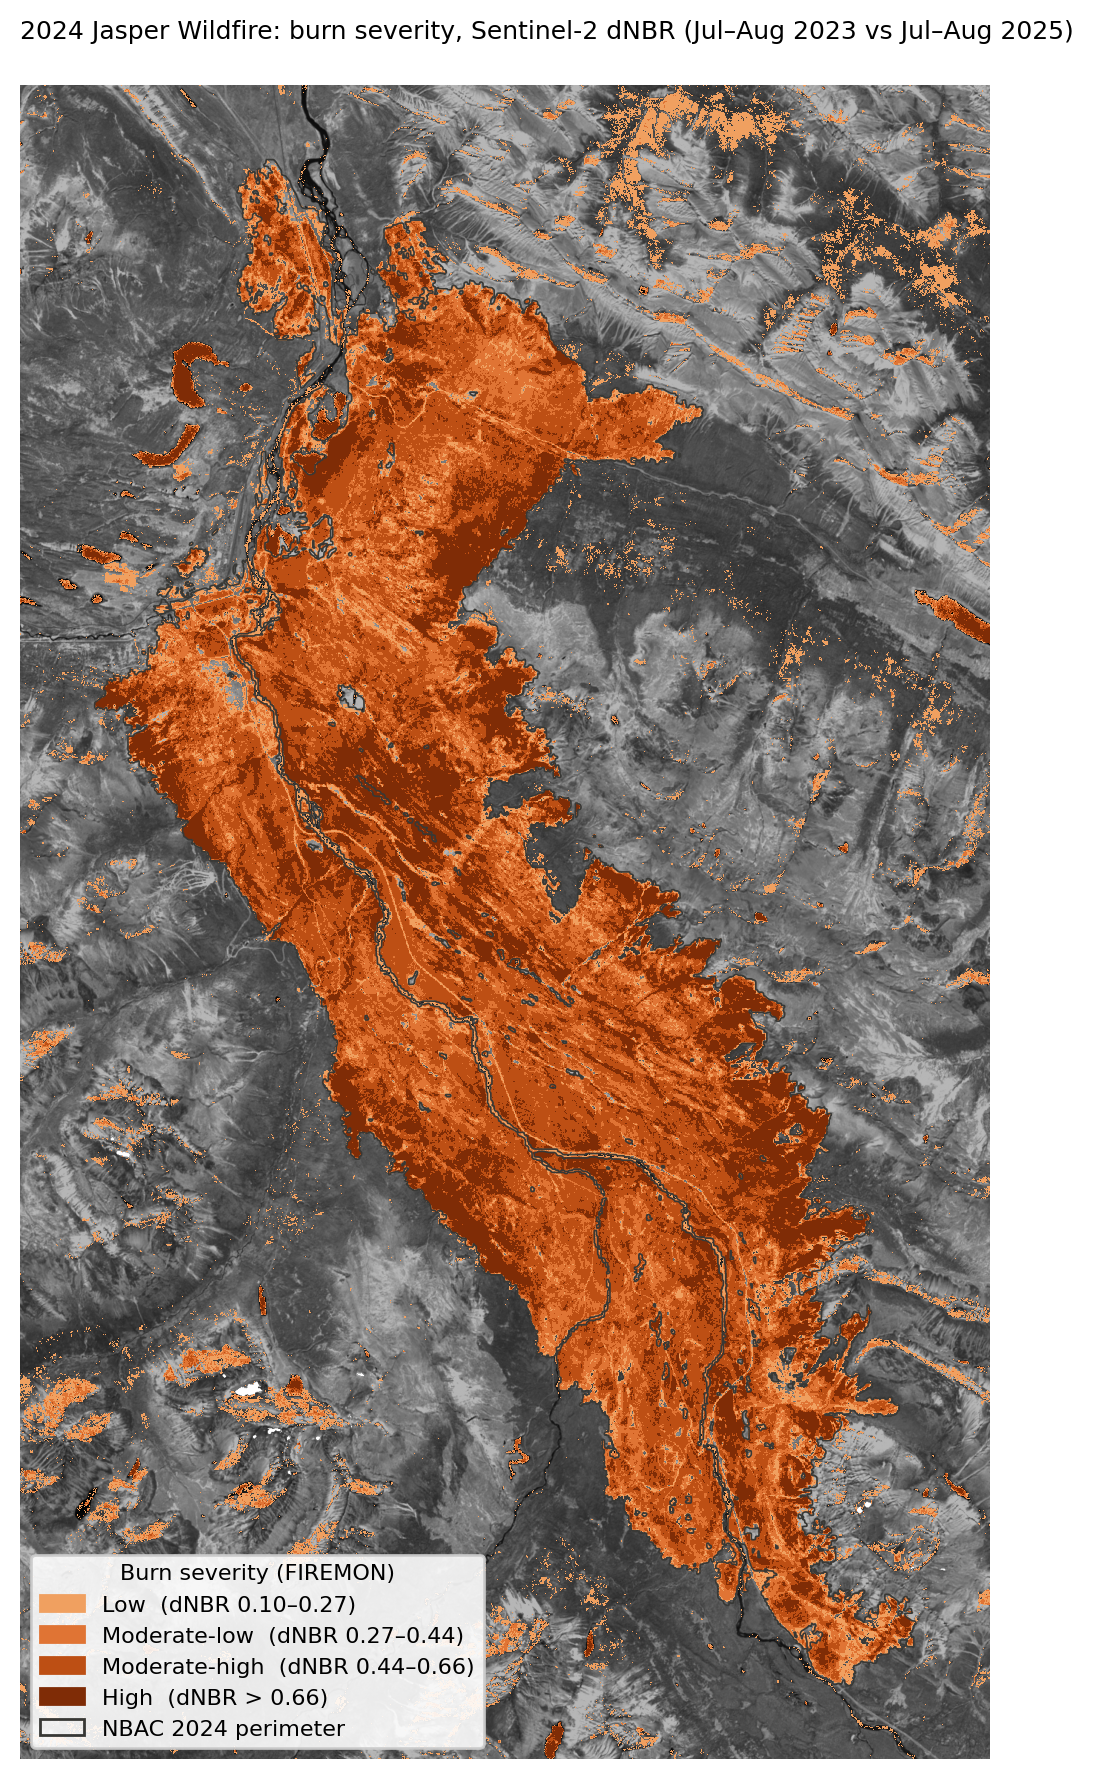

In [8]:
# Ordinal one-hue ramp (Low -> High), validated with the dataviz validator (--ordinal, light surface)
SEV_COLORS = ["#f0a060", "#e07434", "#bd4f14", "#7f2c06"]
cmap = ListedColormap(SEV_COLORS)
ext = [float(d.x.min()), float(d.x.max()), float(d.y.min()), float(d.y.max())]

base = post["B8A"]
base = (base / base.quantile(0.98)).clip(0, 1)
burned = sev.where(sev >= 1) - 1                                   # 0..3 -> Low..High; unburned transparent

fig, ax = plt.subplots(figsize=(8, 9), dpi=200)
ax.imshow(base, cmap="gray", vmin=0, vmax=1.4, extent=ext)          # vmax>1 keeps the basemap recessive
ax.imshow(burned, cmap=cmap, vmin=-0.5, vmax=3.5, extent=ext, interpolation="nearest")
perim.boundary.plot(ax=ax, color="#383835", lw=0.6)
ranges = ["0.10–0.27", "0.27–0.44", "0.44–0.66", "> 0.66"]
ax.legend(handles=[Patch(color=c, label=f"{l}  (dNBR {r})") for c, l, r in zip(SEV_COLORS, SEVERITY_LABELS[1:], ranges)]
          + [Patch(facecolor="none", edgecolor="#383835", label="NBAC 2024 perimeter")],
          loc="lower left", frameon=True, framealpha=0.9, fontsize=8, title="Burn severity (FIREMON)", title_fontsize=8)
ax.set_title("2024 Jasper Wildfire: burn severity, Sentinel-2 dNBR (Jul–Aug 2023 vs Jul–Aug 2025)", fontsize=9, loc="left")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(FIG / "severity_map.png", bbox_inches="tight")

## 4. Save

In [9]:
d.rio.to_raster(DATA / "dnbr_2023_2025.tif", compress="deflate")
sev.fillna(255).astype("uint8").rio.write_nodata(255).rio.to_raster(DATA / "severity_2023_2025.tif", compress="deflate")
area.to_csv(FIG / "severity_area_inside_perimeter.csv", index=False)
print("saved")

saved
